# Holiday Package Prediction

## Problem Statement 
"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering - Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [6]:
df = pd.read_csv('Travel.csv')
df.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

## Data Cleaning
1. Handlng Missing Value
2. Handling Duplicates
3. Check the data type
4. Understand the dataset

In [8]:
df.isnull().sum()

CustomerID                    0
ProdTaken                     0
Age                         226
TypeofContact                25
CityTier                      0
DurationOfPitch             251
Occupation                    0
Gender                        0
NumberOfPersonVisiting        0
NumberOfFollowups            45
ProductPitched                0
PreferredPropertyStar        26
MaritalStatus                 0
NumberOfTrips               140
Passport                      0
PitchSatisfactionScore        0
OwnCar                        0
NumberOfChildrenVisiting     66
Designation                   0
MonthlyIncome               233
dtype: int64

In [9]:
# Check Missing Values
feature_with_na = [features for features in df.columns if df[features].isnull().sum() >= 1]
for feature in feature_with_na : 
    print(feature , np.round(df[feature].isnull().mean() *100 , 5) , '% mising value')

Age 4.62357 % mising value
TypeofContact 0.51146 % mising value
DurationOfPitch 5.13502 % mising value
NumberOfFollowups 0.92062 % mising value
PreferredPropertyStar 0.53191 % mising value
NumberOfTrips 2.86416 % mising value
NumberOfChildrenVisiting 1.35025 % mising value
MonthlyIncome 4.76678 % mising value


In [10]:
df[feature_with_na].select_dtypes(exclude='object').describe()

,Age,DurationOfPitch,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
count,4662.000000,4637.000000,4843.000000,4862.000000,4748.000000,4822.000000,4655.000000
mean,37.622265,15.490835,3.708445,3.581037,3.236521,1.187267,23619.853491
std,9.316387,8.519643,1.002509,0.798009,1.849019,0.857861,5380.698361
min,18.000000,5.000000,1.000000,3.000000,1.000000,0.000000,1000.000000
25%,31.000000,9.000000,3.000000,3.000000,2.000000,1.000000,20346.000000
50%,36.000000,13.000000,4.000000,3.000000,3.000000,1.000000,22347.000000
75%,44.000000,20.000000,4.000000,4.000000,4.000000,2.000000,25571.000000
max,61.000000,127.000000,6.000000,5.000000,22.000000,3.000000,98678.000000


## Imputting Null Values
1. Impute Median value for Age Column
2. Impute Mode for Type of Contact
3. Impute Median for Duration of Pitch
4. Impute Mode for Number of follow ups  as it is discrete feature
5. Impute Mode for Prefered Property Star
6. Impute Median for Number of Trips 
7. Impute Mode for Number of Children Visiting
8. Impute Median for Monthly Income

In [11]:
df['Age'].fillna(df['Age'].median() , inplace=True)
# 1. Fixing the TypeofContact Column if there is nan we filled with mode of the column 
df['TypeofContact'].fillna(df['TypeofContact'].mode()[0] , inplace=True)

# 1. Removing NaN value from the Duration of Pitch Column
# 2. Instead of NaN we replace it by Mean or Median Value of the Column
df['DurationOfPitch'].fillna(df['DurationOfPitch'].median() , inplace=True)

# 1. Fixing the NaN Values of column Number Of Followw Ups
# 2. By Replacing the Mode values
df['NumberOfFollowups'].fillna(df['NumberOfFollowups'].mode()[0] , inplace=True)

# 1. Replacing the NaN value to the Mode of the Column
df['PreferredPropertyStar'].fillna(df['PreferredPropertyStar'].mode()[0] , inplace=True)

# 1. Replacing the NaN Value with Median of the Column
df["NumberOfTrips"].fillna(df['NumberOfTrips'].median() , inplace=True)

# 1. Fixing the NaN by replacing with it by mode of the column value
df['NumberOfChildrenVisiting'].fillna(df['NumberOfChildrenVisiting'].mode()[0] , inplace=True)

# 1. Replacing NaN with Median Value
df['MonthlyIncome'].fillna(df['MonthlyIncome'].median() , inplace=True)


In [12]:
df.isnull().sum()

CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64

In [13]:
# 1. Fixing the Marital Status Issue
# 2. Replace Single with Unmarried
df['MaritalStatus'].replace({
    "Single" : "Unmarried"
} , inplace=True)

# 1. Fixing the Issue of Gender Column 
# 2. Replacing the Fe Male to Female 
df['Gender'].replace({
    "Fe Male" : "Female"
} , inplace=True)

In [14]:
df.MaritalStatus.unique()

array(['Unmarried', 'Divorced', 'Married'], dtype=object)

In [15]:
df.drop("CustomerID" , inplace=True , axis=1)

In [ ]:
df.columns

## Observation
1. All Column have not a NaN Value now
2. Nan Value is Replace with Mean , Median or Mode 

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ProdTaken                 4888 non-null   int64  
 1   Age                       4888 non-null   float64
 2   TypeofContact             4888 non-null   object 
 3   CityTier                  4888 non-null   int64  
 4   DurationOfPitch           4888 non-null   float64
 5   Occupation                4888 non-null   object 
 6   Gender                    4888 non-null   object 
 7   NumberOfPersonVisiting    4888 non-null   int64  
 8   NumberOfFollowups         4888 non-null   float64
 9   ProductPitched            4888 non-null   object 
 10  PreferredPropertyStar     4888 non-null   float64
 11  MaritalStatus             4888 non-null   object 
 12  NumberOfTrips             4888 non-null   float64
 13  Passport                  4888 non-null   int64  
 14  PitchSat

## Feature Engineering

In [18]:
df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,0.0,Manager,20993.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Unmarried,7.0,1,3,0,0.0,Executive,17090.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [19]:
# Create new column for feature
df['TotalVisiting'] = df["NumberOfPersonVisiting"] + df['NumberOfChildrenVisiting']
df.drop(columns=["NumberOfPersonVisiting" , "NumberOfChildrenVisiting"] , axis=1 , inplace=True)

In [20]:
df.columns

Index(['ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch',
       'Occupation', 'Gender', 'NumberOfFollowups', 'ProductPitched',
       'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport',
       'PitchSatisfactionScore', 'OwnCar', 'Designation', 'MonthlyIncome',
       'TotalVisiting'],
      dtype='object')

In [21]:
# Get All Numeric Features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O' ]
print("Number of Numeric Feature : " , len(num_features))

Number of Numeric Feature :  12


In [22]:
# Get All Categorical Features
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O' ]
print("Number of Categorical Features : " , len(categorical_features))

Number of Categorical Features :  6


In [23]:
# Get All Discrete Features
discrete_features = [feature for feature in df.columns if len(df[feature].unique()) <= 25 ]
print("Number of Discrete Features : " , len(discrete_features))

Number of Discrete Features :  15


In [24]:
# Get All Continious Features
continious_features = [feature for feature in df.columns if len(df[feature].unique()) >= 25 ]
print("Number of Continious Features : " , len(continious_features))

Number of Continious Features :  3


In [26]:
from sklearn.model_selection import train_test_split
# Dependent and Independent Features
X = df.drop('ProdTaken' , axis=1)
y = df[['ProdTaken']]


In [27]:
X.head()

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


In [28]:
y.head()

,ProdTaken
0,1
1,0
2,1
3,0
4,0


In [29]:
y.value_counts()

ProdTaken
0            3968
1             920
Name: count, dtype: int64

## Observation 
1. It is an Imbalance dataset 
2. But Random forest or any bagging or boosting techniques are perform well with imbalanced dataset

In [31]:
X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size=0.2 , random_state=42
)
X_train.shape , X_test.shape

((3910, 17), (978, 17))

In [32]:
# Create Column Transformer with 3 types of Transformers
cat_features = X.select_dtypes(include='object').columns
num_features = X.select_dtypes(exclude='object').columns

from sklearn.preprocessing import OneHotEncoder , StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first')

preprocesser = ColumnTransformer(
    [
        ("OneHotEncoder" , oh_transformer , cat_features) ,
        ("StandardScaler" , numeric_transformer , num_features)
    ]
) 

In [33]:
preprocesser

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('OneHotEncoder', ...), ('StandardScaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [34]:
X_train

,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
3995,36.0,Self Enquiry,1,7.0,Small Business,Male,5.0,Basic,3.0,Unmarried,3.0,0,4,1,Executive,21537.0,3.0
2610,42.0,Self Enquiry,1,21.0,Salaried,Male,4.0,Basic,3.0,Married,6.0,0,4,1,Executive,21129.0,5.0
3083,50.0,Self Enquiry,1,7.0,Large Business,Female,4.0,Basic,5.0,Divorced,4.0,0,4,1,Executive,22258.0,4.0
3973,38.0,Self Enquiry,1,7.0,Salaried,Male,5.0,Deluxe,3.0,Married,3.0,0,5,0,Manager,24671.0,4.0
4044,44.0,Company Invited,1,35.0,Small Business,Female,2.0,Basic,3.0,Unmarried,6.0,0,3,0,Executive,23417.0,7.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,28.0,Self Enquiry,1,10.0,Small Business,Male,5.0,Basic,3.0,Unmarried,2.0,0,1,1,Executive,20723.0,5.0
466,41.0,Self Enquiry,3,8.0,Salaried,Female,3.0,Super Deluxe,5.0,Divorced,1.0,0,5,1,AVP,31595.0,4.0
3092,38.0,Company Invited,3,28.0,Small Business,Female,4.0,Basic,3.0,Divorced,7.0,0,2,1,Executive,21651.0,5.0
3772,28.0,Self Enquiry,3,30.0,Small Business,Female,5.0,Deluxe,3.0,Married,3.0,0,1,1,Manager,22218.0,5.0


In [35]:
X_train = preprocesser.fit_transform(X_train)
X_test = preprocesser.transform(X_test)

In [36]:
pd.DataFrame(X_train)

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,0.679690,0.782966,-0.382245,-0.774151
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,-0.721400,0.690023,0.282777,-0.725271,1.511598,-0.632399,0.679690,0.782966,-0.459799,0.643615
2,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-1.020350,0.282777,1.771041,0.418708,-0.632399,0.679690,0.782966,-0.245196,-0.065268
3,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,...,-0.721400,-1.020350,1.284279,-0.725271,-0.127737,-0.632399,1.408395,-1.277194,0.213475,-0.065268
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,2.400396,-1.720227,-0.725271,1.511598,-0.632399,-0.049015,-1.277194,-0.024889,2.061382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,...,-0.721400,-0.653841,1.284279,-0.725271,-0.674182,-0.632399,-1.506426,0.782966,-0.536973,0.643615
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.455047,-0.898180,-0.718725,1.771041,-1.220627,-0.632399,1.408395,0.782966,1.529609,-0.065268
3907,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.455047,1.545210,0.282777,-0.725271,2.058043,-0.632399,-0.777720,0.782966,-0.360576,0.643615
3908,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,1.455047,1.789549,1.284279,-0.725271,-0.127737,-0.632399,-1.506426,0.782966,-0.252799,0.643615


In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report , accuracy_score , confusion_matrix , precision_score , recall_score , f1_score , roc_auc_score

In [41]:
models = {
    "Logistic Regression" : LogisticRegression() , 
    "Decission Tree" : DecisionTreeClassifier() , 
    "Random Forest" : RandomForestClassifier() ,
    "AdaBoost" : AdaBoostClassifier()
}


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train , y_train)

    # prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Set Performance 
    model_train_accuracy = accuracy_score(y_train , y_train_pred)
    model_train_precission = precision_score(y_train , y_train_pred)
    model_train_recall = recall_score(y_train , y_train_pred)
    model_train_f1_score = f1_score(y_train , y_train_pred)
    model_train_roc_acc_score = roc_auc_score(y_train , y_train_pred)

    # Testing Set Performance
    model_test_accuracy = accuracy_score(y_test , y_test_pred)
    model_test_precission = precision_score(y_test , y_test_pred)
    model_test_recall = recall_score(y_test , y_test_pred)
    model_test_f1_score = f1_score(y_test , y_test_pred)
    model_test_roc_acc_score = roc_auc_score(y_test , y_test_pred)

    print(list(models.keys())[i])

    print("Model Performance for Training Datasets")
    print("Accuracy : {:.4f}".format(model_train_accuracy))
    print("Precission Score : {:.4f}".format(model_train_precission))
    print("Recall Score : {:.4f}".format(model_train_recall))
    print("f1 Score : {:.4f}".format(model_train_f1_score))
    print("ROC AUC Score : {:.4f}".format(model_test_roc_acc_score))

    print("------------------------------------------------")

    print("Model Performance for Test Datasets")
    print("Accuracy : {:.4f}".format(model_test_accuracy))
    print("Precission Score : {:.4f}".format(model_test_precission))
    print("Recall Score : {:.4f}".format(model_test_recall))
    print("f1 Score : {:.4f}".format(model_test_f1_score))
    print("ROC AUC Score : {:.4f}".format(model_test_roc_acc_score))

    print("=" * 35)

Logistic Regression
Model Performance for Training Datasets
Accuracy : 0.8460
Precission Score : 0.7016
Recall Score : 0.3032
f1 Score : 0.4234
ROC AUC Score : 0.6307
------------------------------------------------
Model Performance for Test Datasets
Accuracy : 0.8364
Precission Score : 0.6914
Recall Score : 0.2932
f1 Score : 0.4118
ROC AUC Score : 0.6307
Decission Tree
Model Performance for Training Datasets
Accuracy : 1.0000
Precission Score : 1.0000
Recall Score : 1.0000
f1 Score : 1.0000
ROC AUC Score : 0.8600
------------------------------------------------
Model Performance for Test Datasets
Accuracy : 0.9182
Precission Score : 0.8066
Recall Score : 0.7644
f1 Score : 0.7849
ROC AUC Score : 0.8600
Random Forest
Model Performance for Training Datasets
Accuracy : 1.0000
Precission Score : 1.0000
Recall Score : 1.0000
f1 Score : 1.0000
ROC AUC Score : 0.8306
------------------------------------------------
Model Performance for Test Datasets
Accuracy : 0.9315
Precission Score : 0.97

## Hyper Parameter Tunning

In [44]:
rf_params = {
    "max_depth" : [5 , 8 , 15 , None , 10] ,
    "max_features" : [5 ,7 , 'auto' , 8] ,
    "min_samples_split" : [2 , 8 ,15 ,20] ,
    "n_estimators" : [100 ,200 , 500 , 1000]
}

adaboost_params = {
    "n_estimators" : [50 , 60 , 70 , 80, 90]     
 }

In [45]:
adaboost_params

{'n_estimators': [50, 60, 70, 80, 90]}

In [47]:
# Model List for Hyper Parameter Tunning
randomcv_models = [
    ("RF" , RandomForestClassifier() , rf_params) ,
    ('AB' , AdaBoostClassifier() , adaboost_params)
]

In [48]:
randomcv_models 

[('RF',
  RandomForestClassifier(),
  {'max_depth': [5, 8, 15, None, 10],
   'max_features': [5, 7, 'auto', 8],
   'min_samples_split': [2, 8, 15, 20],
   'n_estimators': [100, 200, 500, 1000]}),
 ('AB', AdaBoostClassifier(), {'n_estimators': [50, 60, 70, 80, 90]})]

In [49]:
from sklearn.model_selection import RandomizedSearchCV

model_params = {}

for name, model, params in randomcv_models:

    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=100,
        cv=5,
        verbose=2,
        n_jobs=-1
    )

    random.fit(X_train, y_train)

    model_params[name] = random.best_params_

for model_name in model_params:
    print(f"Best Params for {model_name}")
    print(model_params[model_name])

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best Params for RF
{'n_estimators': 200, 'min_samples_split': 2, 'max_features': 7, 'max_depth': 15}
Best Params for AB
{'n_estimators': 90}


In [ ]:
models = {
        "Random Forest" : RandomForestClassifier(
        n_estimators=1000 , 
        max_features = 7 ,
        max_depth = None 
        ) ,
        "AdaBoost" : AdaBoostClassifier(  n_estimators=90 ) 
}


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train , y_train)

    # prediction
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training Set Performance 
    model_train_accuracy = accuracy_score(y_train , y_train_pred)
    model_train_precission = precision_score(y_train , y_train_pred)
    model_train_recall = recall_score(y_train , y_train_pred)
    model_train_f1_score = f1_score(y_train , y_train_pred)
    model_train_roc_acc_score = roc_auc_score(y_train , y_train_pred)

    # Testing Set Performance
    model_test_accuracy = accuracy_score(y_test , y_test_pred)
    model_test_precission = precision_score(y_test , y_test_pred)
    model_test_recall = recall_score(y_test , y_test_pred)
    model_test_f1_score = f1_score(y_test , y_test_pred)
    model_test_roc_acc_score = roc_auc_score(y_test , y_test_pred)

    print(list(models.keys())[i])

    print("Model Performance for Training Datasets")
    print("Accuracy : {:.4f}".format(model_train_accuracy))
    print("Precission Score : {:.4f}".format(model_train_precission))
    print("Recall Score : {:.4f}".format(model_train_recall))
    print("f1 Score : {:.4f}".format(model_train_f1_score))
    print("ROC AUC Score : {:.4f}".fmat(model_test_roc_acc_score))

    print("------------------------------------------------")

    print("Model Performance for Training Datasets")
    print("Accuracy : {:.4f}".format(model_test_accuracy))
    print("Precission Score : {:.4f}".format(model_test_precission))
    print("Recall Score : {:.4f}".format(model_test_recall))
    print("f1 Score : {:.4f}".format(model_test_f1_score))
    print("ROC AUC Score : {:.4f}".format(model_test_roc_acc_score))

    print("=" * 35)


Random Forest
Model Performance for Training Datasets
Accuracy : 1.0000
Precission Score : 1.0000
Recall Score : 1.0000
f1 Score : 1.0000
ROC AUC Score : 0.8371
------------------------------------------------
Model Performance for Training Datasets
Accuracy : 0.9325
Precission Score : 0.9630
Recall Score : 0.6806
f1 Score : 0.7975
ROC AUC Score : 0.8371
AdaBoost
Model Performance for Training Datasets
Accuracy : 0.8473
Precission Score : 0.7750
Recall Score : 0.2551
f1 Score : 0.3839
ROC AUC Score : 0.6049
------------------------------------------------
Model Performance for Training Datasets
Accuracy : 0.8364
Precission Score : 0.7818
Recall Score : 0.2251
f1 Score : 0.3496
ROC AUC Score : 0.6049


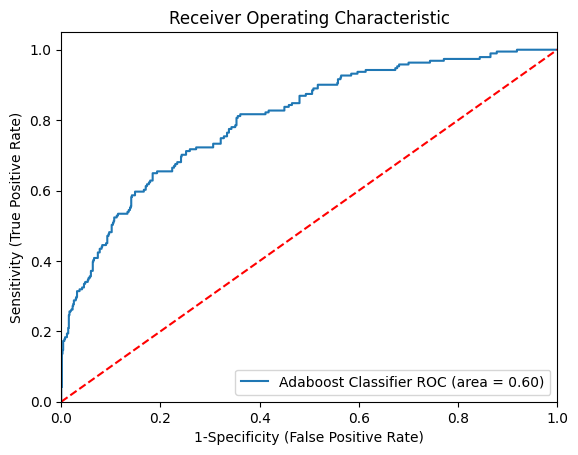

In [59]:
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier

# Add models to evaluate
auc_models = [
    {
        'label': 'Adaboost Classifier',
        'model': AdaBoostClassifier(
            n_estimators=90,
        ),
        'auc': 0.6049
    },
]

# create loop through all model
for algo in auc_models:

    model = algo['model']   # select the model

    # train the model
    model.fit(X_train, y_train)

    # Compute False positive rate and True positive rate
    fpr, tpr, threshold = roc_curve(
        y_test,
        model.predict_proba(X_test)[:, 1]
    )

    # Calculate Area under the curve to display on the plot
    plt.plot(
        fpr,
        tpr,
        label='%s ROC (area = %0.2f)' % (algo['label'], algo['auc'])
    )

# Custom settings for the plot
plt.plot([0, 1], [0, 1], 'r--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('1-Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')

plt.title('Receiver Operating Characteristic')

plt.legend(loc='lower right')

plt.show()